(a) Using Python, Matlab, Mathematica, or your programming language of choice (graphing calculator and hand-drawn not permitted), plot the above equation as a function of lambda for the radiation emitted by the sun, from lambda = 100 nm to lambda = 1000 nm. Ensure that your graph is clearly labelled and professionally presented. For the purpose of this assignment, you can treat the sun as a perfect black body at temperature T = 5775 K. Attach your full code in the appendix of the submission.

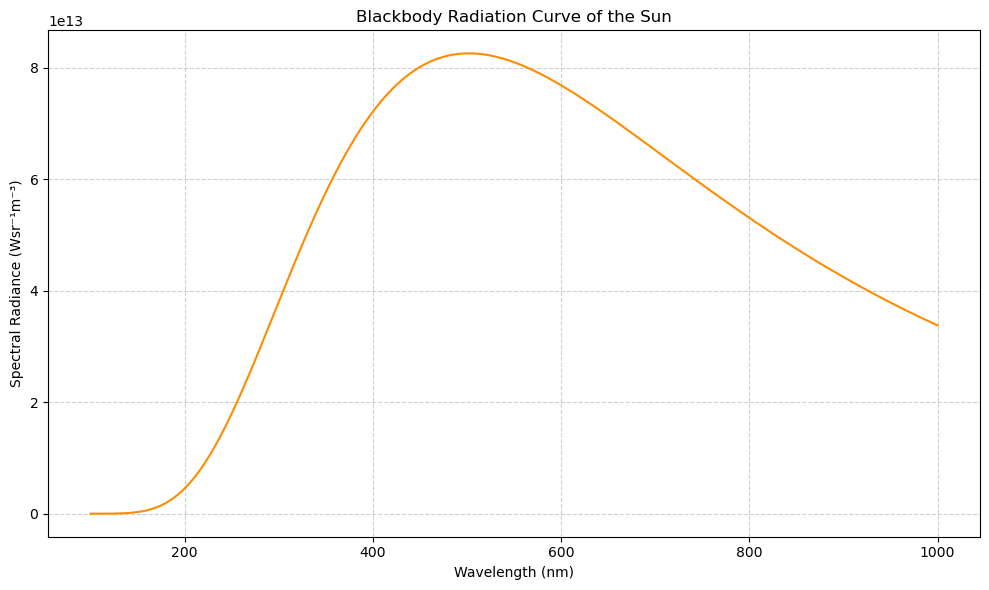

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
h = 6.626e-34       # Planck's constant (J·s)
c = 3e8          # Speed of light in vacuum (m/s)
k = 1.381e-23       # Boltzmann constant (J/K)
T = 5775            # Temperature of the sun (K)

# Wavelengths: 100 nm to 1000 nm (converted to meters)
wavelength_nm = np.linspace(100, 1000, 1000)      # in nanometers for plotting
wavelength_m = wavelength_nm * 1e-9               # convert to meters for calculation

# Planck’s law
def PlancksLaw(wavelength):
    numerator = 2 * np.pi * h * c**2
    exponent = (h * c) / (wavelength * k * T)
    denominator = (wavelength**5) * (np.exp(exponent) - 1)
    spectral_radiance = numerator / denominator
    return spectral_radiance

# The Graph
plt.figure(figsize=(10, 6))
plt.plot(wavelength_nm, PlancksLaw(wavelength_m), color='darkorange', label=f"T = {T} K")
plt.title("Blackbody Radiation Curve of the Sun")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral Radiance (Wsr⁻¹m⁻³)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the graph
plt.show()

(b) What is the peak spectral intensity of the curve and at what wavelength does it occur? Show your work and explain your reasoning in detail [20 marks]

In [22]:
# Wien's displacement constant
b = 2.897771955e-3
lambda_max_theoretical = b / T  # in meters

# Find peak
index_max = np.argmax(PlancksLaw(wavelength_m))
lambda_max_numerical = wavelength_m[index_max]
intensity_max = PlancksLaw(wavelength_m)[index_max]

print(f"Theoretical λ_max (Wien's Dsiplacement Law):  {lambda_max_theoretical*1e9:.2f} nm")
print(f"Numerical λ_max from plot:       {lambda_max_numerical*1e9:.2f} nm")
print(f"Peak Spectral Radiance:          {intensity_max:.2e} W·sr⁻¹·m⁻³")

Theoretical λ_max (Wien's Dsiplacement Law):  501.78 nm
Numerical λ_max from plot:       501.80 nm
Peak Spectral Radiance:          8.26e+13 W·sr⁻¹·m⁻³


(c) What is the total intensity emitted by the sun in the visible range i.e., between lambda = 400 nm and lambda = 700 nm? You may need to perform an integral computationally to answer this question -- the integral has to be implemented in a programming language and not performed by a graphing calculator. Show your work and explain your reasoning in detail. Attach your full code in the appendix of your submission. [20 marks]

In [23]:
import scipy.integrate as integrate

visible_intensity, _ = integrate.quad(PlancksLaw, 400e-9, 700e-9)

print(f"Total intensity in visible range (400 - 700 nm): {visible_intensity:.2e} W·m⁻²")

Total intensity in visible range (400 - 700 nm): 2.31e+07 W·m⁻²


(d) What fraction of the sun's total power reaches the earth and its atmosphere? For the purpose of this question, you may treat the earth as a perfect sphere of radius 6370 km, located 1.496×10^8 km from the sun, and the sun as a perfect sphere of radius 696340 km. Show your work and explain your reasoning in detail [20 marks]

In [24]:
# Constants
R_earth = 6370e3               # Earth radius in meters
R_sun = 696340e3               # Sun radius in meters
D = 1.496e11                   # Earth-Sun distance in meters
T_sun = 5775                   # Sun surface temperature (K)
sigma = 5.670374419e-8         # Stefan-Boltzmann constant (W·m⁻²·K⁻⁴)

# Total power output of the Sun
A_sun = 4 * np.pi * R_sun**2
P_sun = sigma * A_sun * T_sun**4

# Fraction of Sun's power intercepted by Earth
fraction = (R_earth**2) / (4 * D**2)
P_earth = fraction * P_sun

# Output
print(f"Total power output of the Sun:     {P_sun:.3e} W")
print(f"Fraction reaching Earth:           {fraction:.3e}")
print(f"Power intercepted by Earth:        {P_earth:.3e} W")

Total power output of the Sun:     3.843e+26 W
Fraction reaching Earth:           4.533e-10
Power intercepted by Earth:        1.742e+17 W


(e) Using the code you have written in the previous parts, answer the question about which color reaching the earth and its atmosphere is the most intense. For this question you may consider the 7 colors to have the wavelength ranges in Table 1. Show your work and explain your reasoning in detail. Attach your full code in the appendix of your submission. [20 marks]

In [26]:
# Color wavelength ranges (in meters)
color_ranges = {
    'Red':    (625e-9, 740e-9),
    'Orange': (590e-9, 625e-9),
    'Yellow': (565e-9, 590e-9),
    'Green':  (520e-9, 565e-9),
    'Cyan':   (500e-9, 520e-9),
    'Blue':   (435e-9, 500e-9),
    'Purple': (380e-9, 435e-9)
}

# Calculate total intensity for each color
intensities = {}
for color, (λ_min, λ_max) in color_ranges.items():
    intensity, _ = integrate.quad(PlancksLaw, λ_min, λ_max)
    bandwidth = (λ_max - λ_min)
    avg_intensity = intensity / bandwidth  # W/m² per meter (Normalising the Range)
    intensities[color] = avg_intensity

# Find the color with maximum intensity
most_intense = max(intensities, key=intensities.get)

# Print results
print("Color Intensities (W/m²):")
for color, intensity in intensities.items():
    print(f"{color}: {intensity:.3e}")

print(f"\nMost Intense Color: {most_intense}")

Color Intensities (W/m²):
Red: 6.733e+13
Orange: 7.607e+13
Yellow: 7.893e+13
Green: 8.134e+13
Cyan: 8.251e+13
Blue: 8.120e+13
Purple: 7.340e+13

Most Intense Color: Cyan
